Lectura del archivo y normalizacion del archivo y lecutra de los modulos de la automatizacion


In [14]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import sys
import os
import pandas as pd
from pathlib import Path



# 1. Detectar raíz del proyecto (subiendo desde el cwd)
project_root = Path(os.getcwd()).resolve().parent  # sube un nivel desde notebooks/
sys.path.append(str(project_root))

# 2. Ruta hacia el módulo src/
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# 3. Importar módulos desde src/
from src.data_loading import (
    cargar_datos_excel
)
from src.data_cleaning import (
    estandarizar_columnas,
    convertir_fechas,
)
from src.logistica import (
    calcular_tiempo_entrega,    
)
from src.exportacion import (
    exportar_excel,
)




In [16]:
ruta_excel = "../data/raw/Sales report completa.xlsx" 
df = cargar_datos_excel(ruta_excel, sheet_name="Ventas Supermercado")
df = estandarizar_columnas(df)
df = convertir_fechas(df)
df = calcular_tiempo_entrega(df)

visualizacion de las columnas utilizando jupyter

In [17]:
pd.DataFrame(df.columns, columns=['Columnas'])


,Columnas
0,numero_venta
1,mes_salida
2,dia_salida
3,ano_salida
4,mes_entrega
5,dia_entrega
6,ano_entrega
7,metodo_envio
8,numero_cliente
9,nombre_cliente


medias estadisticas para analisis del tiempo de entrega

In [ ]:
df['tiempo_entrega'].describe()


count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: tiempo_entrega, dtype: float64

visualizacion de las estadisticas por medio de boxplots se identifica una posible inconsistencia en la visualizacion y posible duplicacion por espacios adicionales

/tmp/ipykernel_2031/3444460739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='metodo_envio', y='tiempo_entrega', palette='Set2')


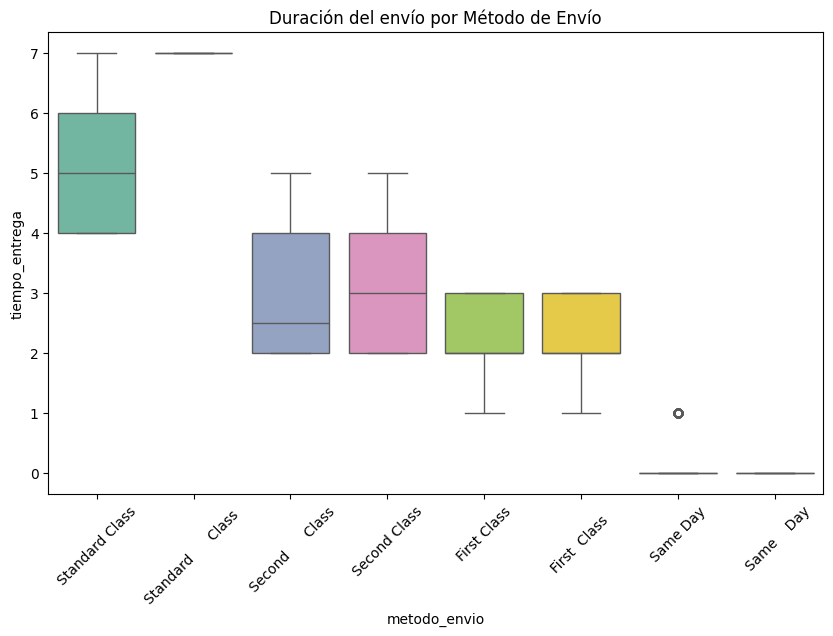

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='metodo_envio', y='tiempo_entrega', palette='Set2')
plt.title('Duración del envío por Método de Envío')
plt.xticks(rotation=45)
plt.show()


codigo para realizar limpieza de imformacion strip para quitar espacios al principio y al final y regex para espacios internos

In [ ]:
df['metodo_envio'] = df['metodo_envio'].str.strip().str.replace(r'\s+', ' ', regex=True)


columna normalizada

In [ ]:
df['metodo_envio'].unique()


array(['Standard Class', 'Second Class', 'First Class', 'Same Day'],
      dtype=object)

In [ ]:
boxplot de comparativa entre metodo_envio y prioridad_envio en el cual se puede observar que la duración del envío es mayor en los métodos de envío con prioridad alta, lo que indica que los metodos de envio se comportan según el tipo

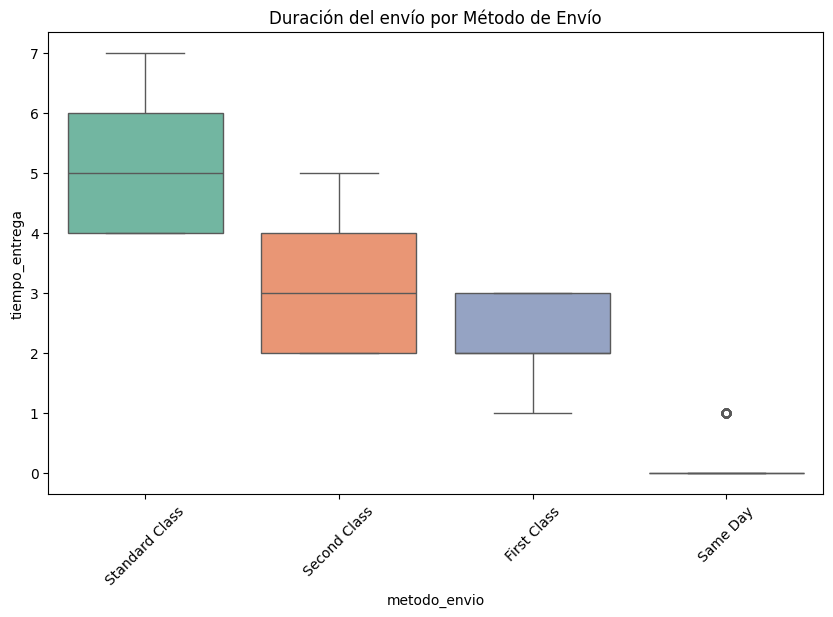

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='metodo_envio',
    y='tiempo_entrega',
    hue='metodo_envio',
    palette='Set2',
    legend=False
)
plt.title('Duración del envío por Método de Envío')
plt.xticks(rotation=45)
plt.show()


In [ ]:
en este boxplot se obsesrvan datos atipicos en la prioridad medium 

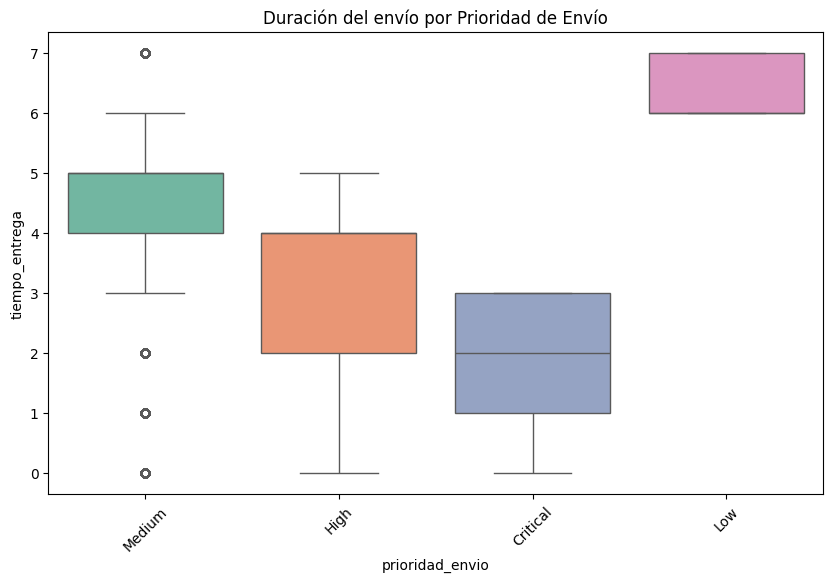

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='prioridad_envio',
    y='tiempo_entrega',
    hue='prioridad_envio',
    palette='Set2',
    legend=False
)
plt.title('Duración del envío por Prioridad de Envío')
plt.xticks(rotation=45)
plt.show()


In [ ]:
boxplot tiempo de entrega por pais que se satura por la cantidad de paises que se tienen en el dataset punto de partidad para definir que segmentacion o grafica presente los datos de una manera mas clara

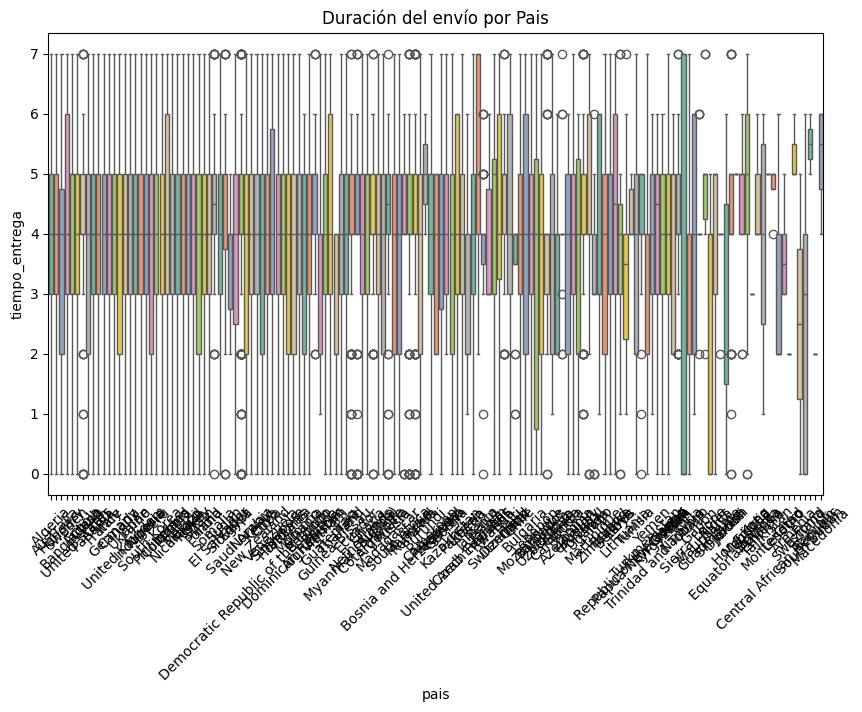

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='pais',
    y='tiempo_entrega',
    hue='pais',
    palette='Set2',
    legend=False
)
plt.title('Duración del envío por Pais')
plt.xticks(rotation=45)
plt.show()

inicio de analisis geografico

In [ ]:
print('Países únicos:', df['pais'].nunique())

Países únicos: 147


In [ ]:
print('Ciudades únicas:', df['ciudad'].nunique())

Ciudades únicas: 3636


In [ ]:
# Agrupar por país y contar ciudades únicas
ciudades_por_pais = df.groupby('pais')['ciudad'].nunique().reset_index().sort_values(by='ciudad', ascending=False)

ciudades_por_pais.columns = ['pais', 'num_ciudades']
print(ciudades_por_pais.head(10))


               pais  num_ciudades
139   United States           531
44           France           405
17           Brazil           254
26            China           240
138  United Kingdom           164
47          Germany           155
57            India           146
63            Italy           127
81           Mexico           122
133          Turkey           101


In [ ]:
# Ver cuántas filas hay por ciudad dentro de cada país
conteo = df.groupby(['pais', 'ciudad']).size().reset_index(name='num_envios')

print(conteo.head(10))


          pais       ciudad  num_envios
0  Afghanistan        Herat           5
1  Afghanistan    Jalalabad           5
2  Afghanistan        Kabul          41
3  Afghanistan     Kandahar           4
4      Albania       Durres           2
5      Albania      Elbasan           1
6      Albania        Korce           3
7      Albania      Shkoder           4
8      Albania        Vlore           6
9      Algeria  Ain Oussera           3


In [ ]:
df['estado']


0             Constantine
1         New South Wales
2                Budapest
3               Stockholm
4         New South Wales
               ...       
51285          California
51286    Souss-Massa-Draâ
51287             Managua
51288           Chihuahua
51289            Colorado
Name: estado, Length: 51290, dtype: object

In [ ]:
# Agrupar por país y contar ciudades únicas
ciudades_por_pais = df.groupby('pais')['ciudad'].nunique().reset_index().sort_values(by='ciudad', ascending=False)

ciudades_por_pais.columns = ['pais', 'num_ciudades']
print(ciudades_por_pais.head(10))


               pais  num_ciudades
139   United States           531
44           France           405
17           Brazil           254
26            China           240
138  United Kingdom           164
47          Germany           155
57            India           146
63            Italy           127
81           Mexico           122
133          Turkey           101


In [ ]:
# Contar número de envíos por ciudad
top_ciudades = df.groupby(['pais', 'ciudad']).size().reset_index(name='num_envios')

# Ordenar de mayor a menor
top_ciudades = top_ciudades.sort_values(by='num_envios', ascending=False)

# Mostrar primeras filas
print(top_ciudades.head(10))


                    pais         ciudad  num_envios
3427       United States  New York City         915
3364       United States    Los Angeles         747
3472       United States   Philadelphia         537
3536       United States  San Francisco         510
915   Dominican Republic  Santo Domingo         443
2437         Philippines         Manila         432
3550       United States        Seattle         428
3305       United States        Houston         377
1561            Honduras    Tegucigalpa         362
1726           Indonesia        Jakarta         337


In [ ]:
# Tomar solo las 20 ciudades con más envíos
top20_ciudades = top_ciudades.head(20)


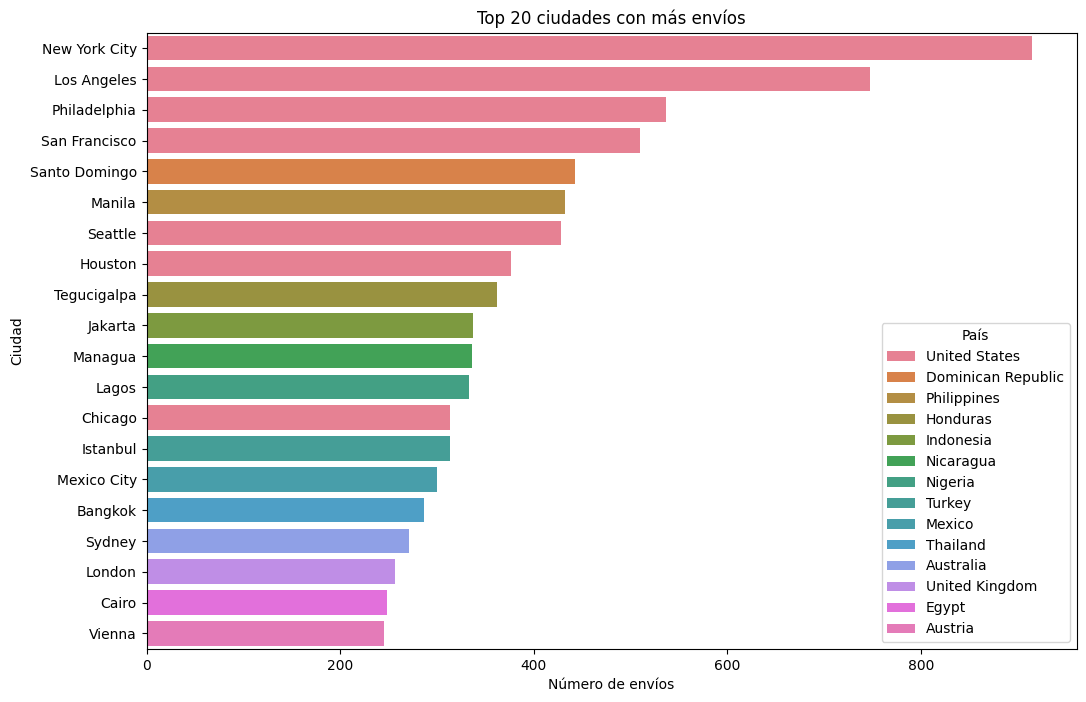

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.barplot(
    data=top20_ciudades,
    y='ciudad',
    x='num_envios',
    hue='pais',
    dodge=False
)

plt.title('Top 20 ciudades con más envíos')
plt.xlabel('Número de envíos')
plt.ylabel('Ciudad')
plt.legend(title='País')
plt.show()
